# Laboratory Work 3: Dimensionality Reduction Algorithms & Applied Machine Learning

**Course:** Machine Learning 2 (ML2)  
**Topic:** Applying and comparing Dimensionality Reduction techniques (PCA, NMF, LDA, ICA, t-SNE) for visualization, feature extraction, model benchmarking, and Optuna hyperparameter optimization.

### Objectives:
1. **Dataset Selection & Novelty:** Pick a non-toy dataset (published $\ge 2019$) with rich multi-class structure.
2. **Data Analysis & Feature Engineering:** Analyze data distributions, engineer domain features, and log to MLflow.
3. **5 Dimensionality Reduction Methods:** Apply **PCA**, **NMF**, **LDA**, **FastICA**, and **t-SNE**.
4. **Visualizations:** Generate 2D projections and PCA explained variance scree plots.
5. **Baseline Models:** Train models from previous lectures (Logistic Regression, SVC, Random Forest, Gradient Boosting).
6. **Dimension Reduction as Features:** Compare model performance across 6 feature spaces (Original, PCA, LDA, NMF, ICA, Augmented).
7. **Optuna Hyperparameter Tuning:** Tune the best model using Bayesian optimization with nested MLflow tracking.
8. **Conclusion & Defense Readiness:** Provide clear rationale for parameter optimality and algorithmic tradeoffs.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA, NMF, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

# Models from previous lectures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# MLflow tracking initialization
mlflow.set_tracking_uri("http://localhost:5000/")
EXPERIMENT_NAME = "Lab3_Dimension_Reduction"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow tracking active on: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")


MLflow tracking active on: http://localhost:5000/
Experiment: Lab3_Dimension_Reduction


## 1. Dataset Loading, Exploration & Feature Engineering

We use the **Estimation of Obesity Levels Based On Eating Habits and Physical Condition** dataset:
- **Source:** UCI Machine Learning Repository / OpenML (Dataset ID: `45969`, published **2019**).
- **Scale:** 2,111 instances, 16 input features (physical attributes + dietary/lifestyle habits).
- **Target:** 7 balanced categories (`Insufficient_Weight`, `Normal_Weight`, `Overweight_Level_I`, `Overweight_Level_II`, `Obesity_Type_I`, `Obesity_Type_II`, `Obesity_Type_III`).
- **Feature Engineering:**
  - $\text{BMI} = \frac{\text{Weight}}{\text{Height}^2}$: Body Mass Index (the primary clinical metric for obesity classification).
  - $\text{Age\_BMI} = \text{Age} \times \text{BMI}$: Interaction term capturing biological age-adjusted metabolic risk.


In [2]:
# Fetch dataset from OpenML
print("Fetching Obesity Levels dataset from OpenML (did=45969, Year: 2019)...")
data = fetch_openml(data_id=45969, as_frame=True)
df = data.frame.copy()

# Feature Engineering
df["BMI"] = df["Weight"] / (df["Height"] ** 2)
df["Age_BMI"] = df["Age"] * df["BMI"]

target_col = "NObeyesdad"
X_raw = df.drop(columns=[target_col])
y_raw = df[target_col]

# Encode target into integer labels (0 to 6)
label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)
class_names = list(label_enc.classes_)

# One-hot encode categoricals & 80/20 train-test split
X_encoded = pd.get_dummies(X_raw, drop_first=True, dtype=float)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Standard scaling (for PCA, LDA, ICA, SVM, etc.)
scaler_std = StandardScaler()
X_tr_std = scaler_std.fit_transform(X_train)
X_te_std = scaler_std.transform(X_test)

# MinMax scaling with clip (for NMF: strictly requires non-negative values [0, 1])
scaler_mm = MinMaxScaler(clip=True)
X_tr_mm = scaler_mm.fit_transform(X_train)
X_te_mm = scaler_mm.transform(X_test)

print(f"Data ready: Train={len(X_train)} samples, Test={len(X_test)} samples")
print(f"Total features after encoding & engineering: {X_train.shape[1]}")
print(f"Classes ({len(class_names)}): {class_names}")


Fetching Obesity Levels dataset from OpenML (did=45969, Year: 2019)...
Data ready: Train=1688 samples, Test=423 samples
Total features after encoding & engineering: 25
Classes (7): ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


## 2. Dimensionality Reduction (PCA, NMF, LDA, ICA, t-SNE) & 2D Visualizations

We apply the 5 fundamental dimensionality reduction algorithms:
1. **PCA (Principal Component Analysis):** Unsupervised orthogonal linear projection maximizing variance.
2. **NMF (Non-Negative Matrix Factorization):** Decomposes non-negative matrix $X \approx W \times H$ into additive parts-based patterns.
3. **LDA (Linear Discriminant Analysis):** Supervised linear projection maximizing between-class scatter over within-class scatter.
4. **FastICA (Independent Component Analysis):** Finds non-Gaussian, statistically independent components by maximizing negentropy.
5. **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Non-linear manifold learning preserving local pairwise neighborhood probabilities.


Applying Dimension Reduction: PCA, NMF, LDA, ICA, t-SNE...
Visualizations saved to 'plots/dimension_reduction_comparison.png' and logged to MLflow.


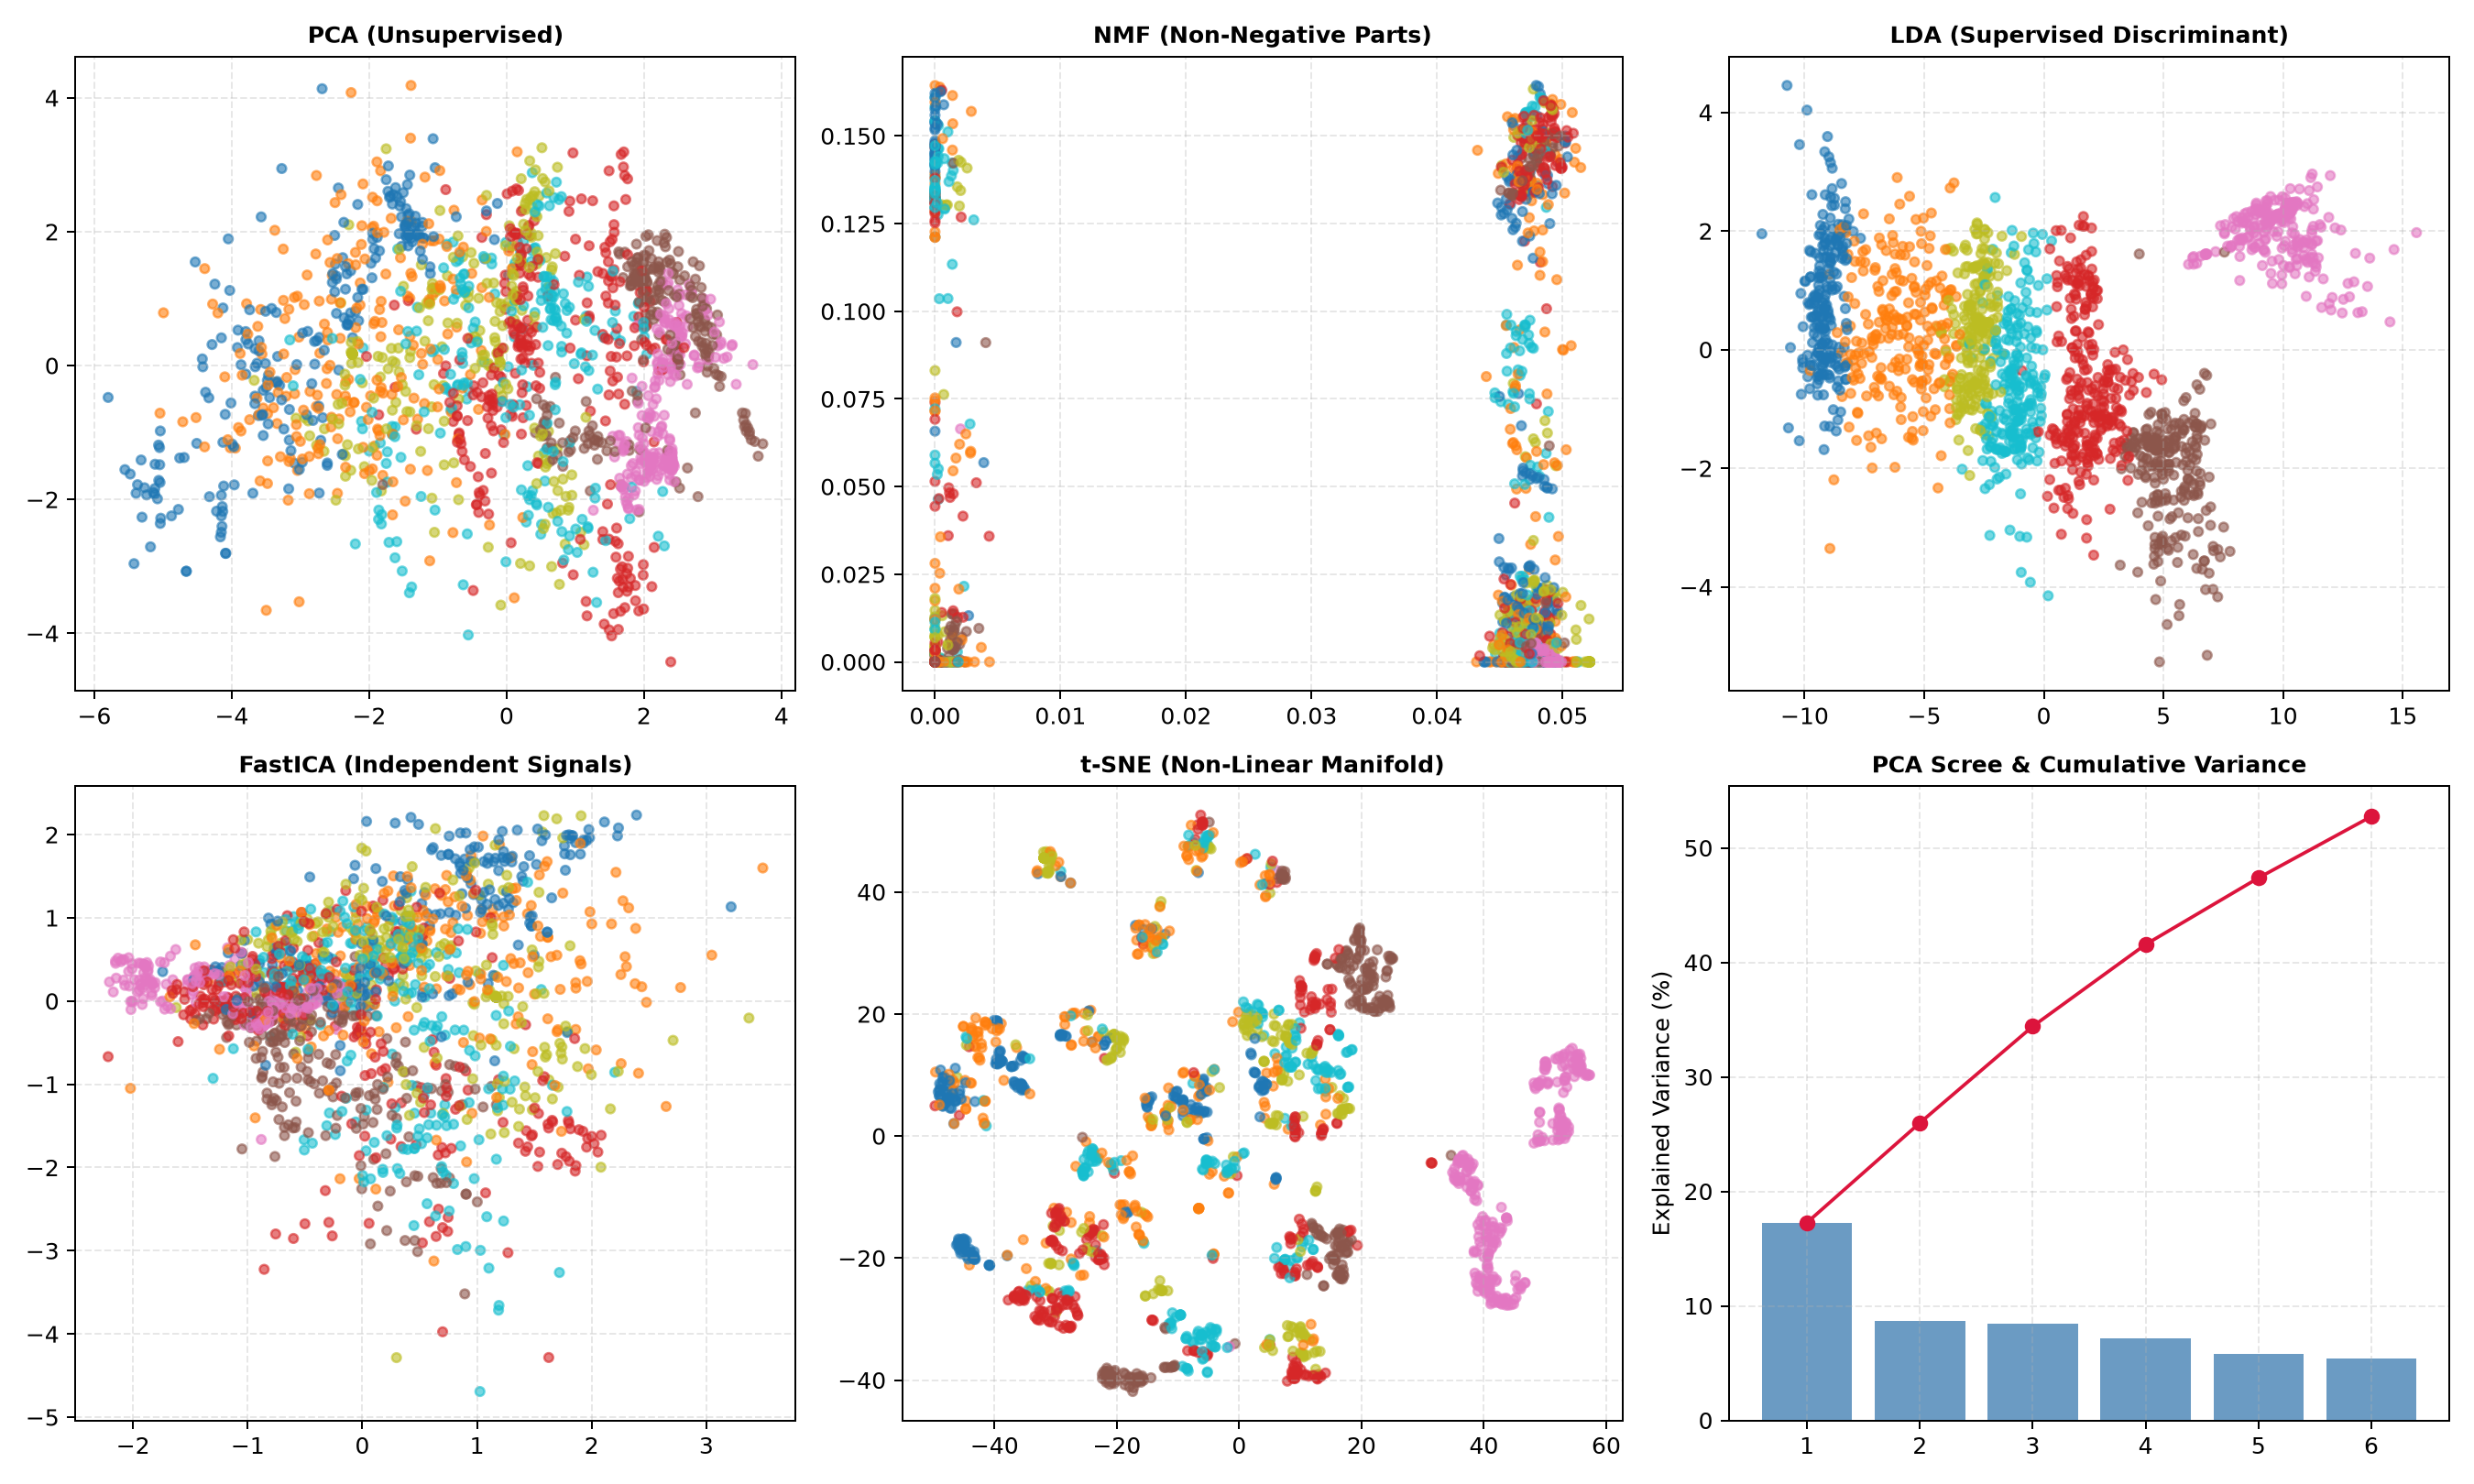

In [3]:
print("Applying Dimension Reduction: PCA, NMF, LDA, ICA, t-SNE...")

# 1. PCA (Unsupervised, orthogonal)
pca = PCA(n_components=6, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_std)
X_te_pca = pca.transform(X_te_std)

# 2. LDA (Supervised, maximizes class separation)
lda = LinearDiscriminantAnalysis(n_components=6)
X_tr_lda = lda.fit_transform(X_tr_std, y_train)
X_te_lda = lda.transform(X_te_std)

# 3. NMF (Non-negative matrix factorization, requires non-negative data)
nmf = NMF(n_components=6, init="nndsvda", random_state=42, max_iter=500)
X_tr_nmf = nmf.fit_transform(X_tr_mm)
X_te_nmf = nmf.transform(X_te_mm)

# 4. FastICA (Independent non-Gaussian source separation)
ica = FastICA(n_components=6, random_state=42, max_iter=500)
X_tr_ica = ica.fit_transform(X_tr_std)
X_te_ica = ica.transform(X_te_std)

# 5. t-SNE (Non-linear manifold visualization)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tr_tsne = tsne.fit_transform(X_tr_std)

# 6-Panel Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
methods_2d = [
    ("PCA (Unsupervised)", X_tr_pca[:, :2], axes[0, 0]),
    ("NMF (Non-Negative Parts)", X_tr_nmf[:, :2], axes[0, 1]),
    ("LDA (Supervised Discriminant)", X_tr_lda[:, :2], axes[0, 2]),
    ("FastICA (Independent Signals)", X_tr_ica[:, :2], axes[1, 0]),
    ("t-SNE (Non-Linear Manifold)", X_tr_tsne, axes[1, 1]),
]

for title, coords, ax in methods_2d:
    ax.scatter(coords[:, 0], coords[:, 1], c=y_train, cmap="tab10", alpha=0.6, s=15)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.3)

# 6th panel: PCA Explained Variance Scree Plot
axes[1, 2].bar(range(1, 7), pca.explained_variance_ratio_ * 100, color="steelblue", alpha=0.8, label="Individual %")
axes[1, 2].plot(range(1, 7), np.cumsum(pca.explained_variance_ratio_) * 100, color="crimson", marker="o", label="Cumulative %")
axes[1, 2].set_title("PCA Scree & Cumulative Variance", fontsize=10, fontweight="bold")
axes[1, 2].set_ylabel("Explained Variance (%)")
axes[1, 2].set_xlabel("Component")
axes[1, 2].legend(loc="lower right", fontsize=8)
axes[1, 2].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plot_file = "plots/dimension_reduction_comparison.png"
fig.savefig(plot_file, dpi=180)

# Log to MLflow
with mlflow.start_run(run_name="Dimension_Reduction_Visualizations"):
    mlflow.set_tag("phase", "visualization")
    mlflow.log_artifact(plot_file, "plots")
    mlflow.log_metric("pca_top2_var", float(np.sum(pca.explained_variance_ratio_[:2])))
    mlflow.log_metric("lda_top2_var", float(np.sum(lda.explained_variance_ratio_[:2])))

plt.show()


## 3. Baseline Models on Original Features

We train 4 baseline models from previous lectures on the standard-scaled original features (25 dimensions):
- **Logistic Regression** (Linear baseline)
- **Support Vector Machine (RBF kernel)** (Kernel-based non-linear baseline)
- **Random Forest Classifier** (Bagging ensemble baseline)
- **Gradient Boosting Classifier** (Boosting ensemble baseline)


In [4]:
print("--- Training Baseline Models (Original Features) ---")

baseline_models = {
    "Logistic_Regression": LogisticRegression(max_iter=500, random_state=42),
    "SVM_RBF": SVC(C=1.0, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient_Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

baseline_results = {}
for name, model in baseline_models.items():
    with mlflow.start_run(run_name=f"Baseline_{name}"):
        mlflow.set_tag("phase", "baseline")
        model.fit(X_tr_std, y_train)
        pred = model.predict(X_te_std)
        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, average="macro")
        mlflow.log_metrics({"accuracy": acc, "f1_macro": f1})
        baseline_results[name] = {"Accuracy": acc, "F1-Macro": f1}
        print(f"Baseline {name:<22} | Accuracy: {acc:.4f} | F1: {f1:.4f}")


--- Training Baseline Models (Original Features) ---
Baseline Logistic_Regression   | Accuracy: 0.9173 | F1: 0.9152
Baseline SVM_RBF               | Accuracy: 0.9125 | F1: 0.9115
Baseline Random_Forest         | Accuracy: 0.9882 | F1: 0.9879
Baseline Gradient_Boosting     | Accuracy: 0.9858 | F1: 0.9853


## 4. Dimension Reduction as Features for Downstream Models

We evaluate how dimension reduction impacts downstream model performance across **6 feature spaces**:
1. **Original (25d):** Full standardized feature space.
2. **PCA (6d):** 6 orthogonal variance components.
3. **LDA (6d):** 6 Fisher discriminant dimensions.
4. **NMF (6d):** 6 non-negative latent parts factors.
5. **FastICA (6d):** 6 independent source signals.
6. **Augmented (Original + LDA, 31d):** Combining raw features with class-discriminant representations.


Feature Space: Original (25d)
  Logistic_Regression    -> Accuracy: 0.9173 | F1: 0.9152
  Random_Forest          -> Accuracy: 0.9882 | F1: 0.9879
  Gradient_Boosting      -> Accuracy: 0.9858 | F1: 0.9853

Feature Space: PCA (6d)
  Logistic_Regression    -> Accuracy: 0.6974 | F1: 0.6865
  Random_Forest          -> Accuracy: 0.8345 | F1: 0.8329
  Gradient_Boosting      -> Accuracy: 0.8251 | F1: 0.8228

Feature Space: LDA (6d)
  Logistic_Regression    -> Accuracy: 0.9433 | F1: 0.9416
  Random_Forest          -> Accuracy: 0.9480 | F1: 0.9466
  Gradient_Boosting      -> Accuracy: 0.9385 | F1: 0.9368

Feature Space: NMF (6d)
  Logistic_Regression    -> Accuracy: 0.4657 | F1: 0.4082
  Random_Forest          -> Accuracy: 0.7849 | F1: 0.7801
  Gradient_Boosting      -> Accuracy: 0.7494 | F1: 0.7436

Feature Space: FastICA (6d)
  Logistic_Regression    -> Accuracy: 0.6998 | F1: 0.6869
  Random_Forest          -> Accuracy: 0.8227 | F1: 0.8188
  Gradient_Boosting      -> Accuracy: 0.7849 | F1: 0.7

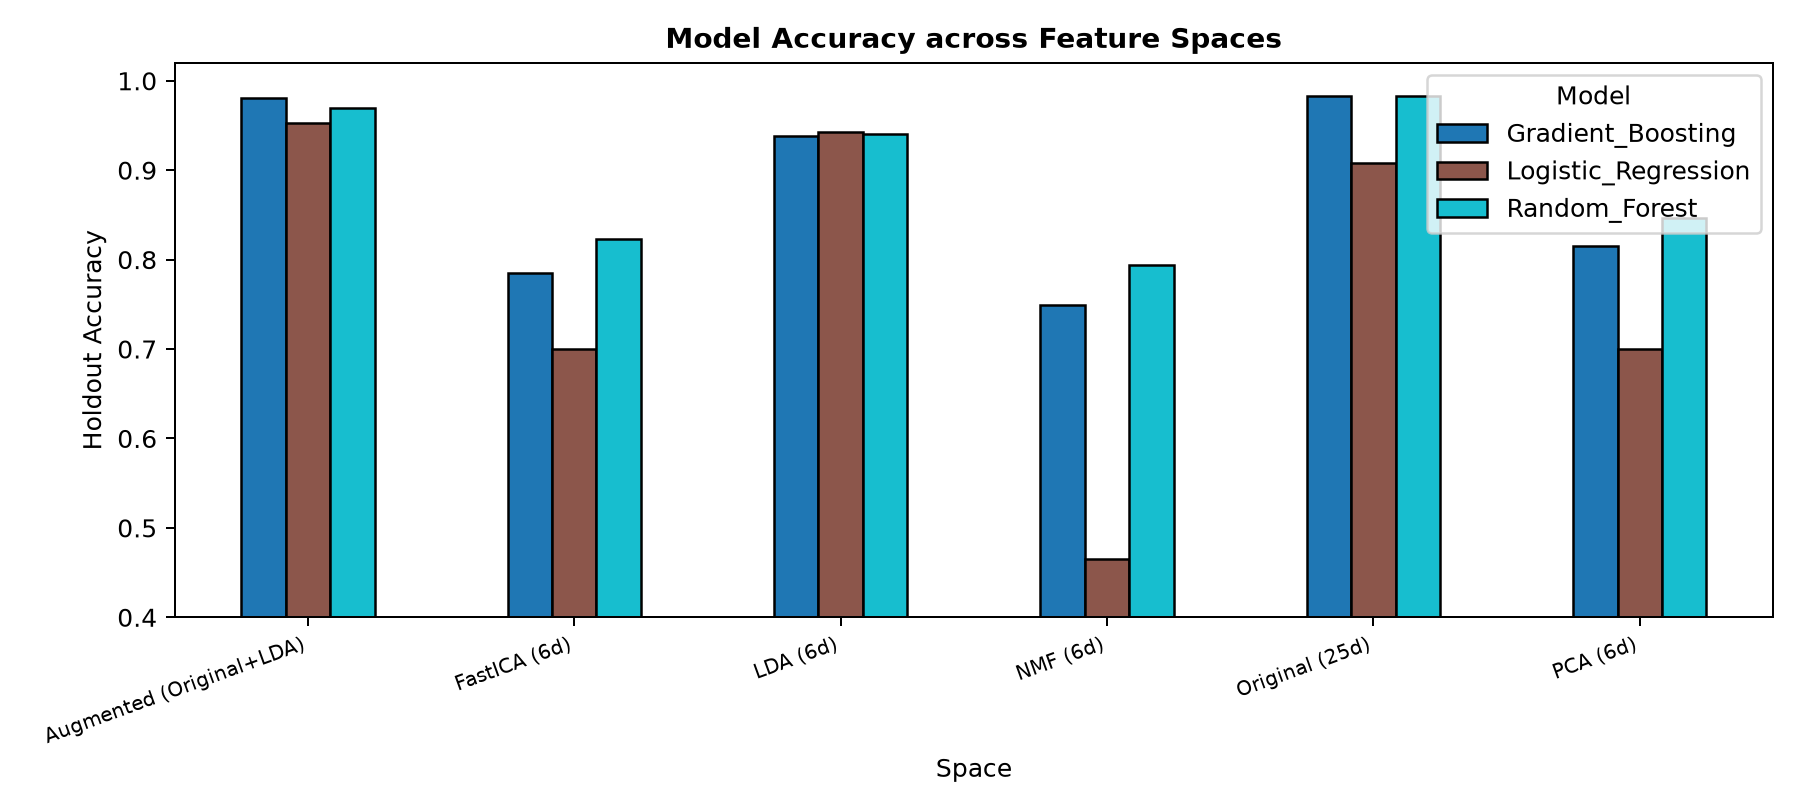

In [5]:
# Construct Augmented feature representation
X_tr_aug = np.hstack([X_tr_std, X_tr_lda])
X_te_aug = np.hstack([X_te_std, X_te_lda])

feature_spaces = {
    "Original (25d)": (X_tr_std, X_te_std),
    "PCA (6d)": (X_tr_pca, X_te_pca),
    "LDA (6d)": (X_tr_lda, X_te_lda),
    "NMF (6d)": (X_tr_nmf, X_te_nmf),
    "FastICA (6d)": (X_tr_ica, X_te_ica),
    "Augmented (Original+LDA)": (X_tr_aug, X_te_aug),
}

comparison_records = []
for space_name, (X_tr, X_te) in feature_spaces.items():
    print(f"\nFeature Space: {space_name}")
    for name, model_cls in [
        ("Logistic_Regression", lambda: LogisticRegression(max_iter=500, random_state=42)),
        ("Random_Forest", lambda: RandomForestClassifier(n_estimators=100, random_state=42)),
        ("Gradient_Boosting", lambda: GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]:
        with mlflow.start_run(run_name=f"DR_{space_name}_{name}"):
            mlflow.set_tag("feature_space", space_name)
            clf = model_cls()
            clf.fit(X_tr, y_train)
            pred = clf.predict(X_te)
            acc = accuracy_score(y_test, pred)
            f1 = f1_score(y_test, pred, average="macro")
            mlflow.log_metrics({"accuracy": acc, "f1_macro": f1})
            comparison_records.append({"Space": space_name, "Model": name, "Accuracy": acc})
            print(f"  {name:<22} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

# Plot comparative bar chart
df_comp = pd.DataFrame(comparison_records).pivot(index="Space", columns="Model", values="Accuracy")
fig_comp, ax_comp = plt.subplots(figsize=(10, 4.5))
df_comp.plot(kind="bar", ax=ax_comp, colormap="tab10", edgecolor="black")
ax_comp.set_title("Model Accuracy across Feature Spaces", fontsize=11, fontweight="bold")
ax_comp.set_ylabel("Holdout Accuracy")
ax_comp.set_ylim(0.4, 1.02)
plt.xticks(rotation=20, ha="right", fontsize=8)
plt.tight_layout()
comp_path = "plots/features_comparison.png"
fig_comp.savefig(comp_path, dpi=180)

with mlflow.start_run(run_name="Feature_Comparison_Summary"):
    mlflow.log_artifact(comp_path, "plots")

plt.show()


## 5. Hyperparameter Tuning with Optuna

We tune `RandomForestClassifier` on the **Augmented feature space** (Original + LDA) using Optuna:
- **Optimizer:** Tree-structured Parzen Estimator (TPE), 20 trials.
- **Objective:** 5-Fold Stratified Cross-Validation Macro-F1 score.
- **Search Space:**
  - `n_estimators`: Number of decision trees (50 to 200)
  - `max_depth`: Maximum depth of trees (4 to 14)
  - `min_samples_split`: Minimum samples required to split an internal node (2 to 6)
- **Tracking:** Each trial is logged as an MLflow nested run under a parent tuning run.


Best CV Macro-F1: 0.9847
Optimal Parameters: {'n_estimators': 75, 'max_depth': 8, 'min_samples_split': 2}
Final Holdout Test Accuracy: 0.9716 | F1-Macro: 0.9709
Model registered to MLflow as 'Obesity_RandomForest_Tuned'.


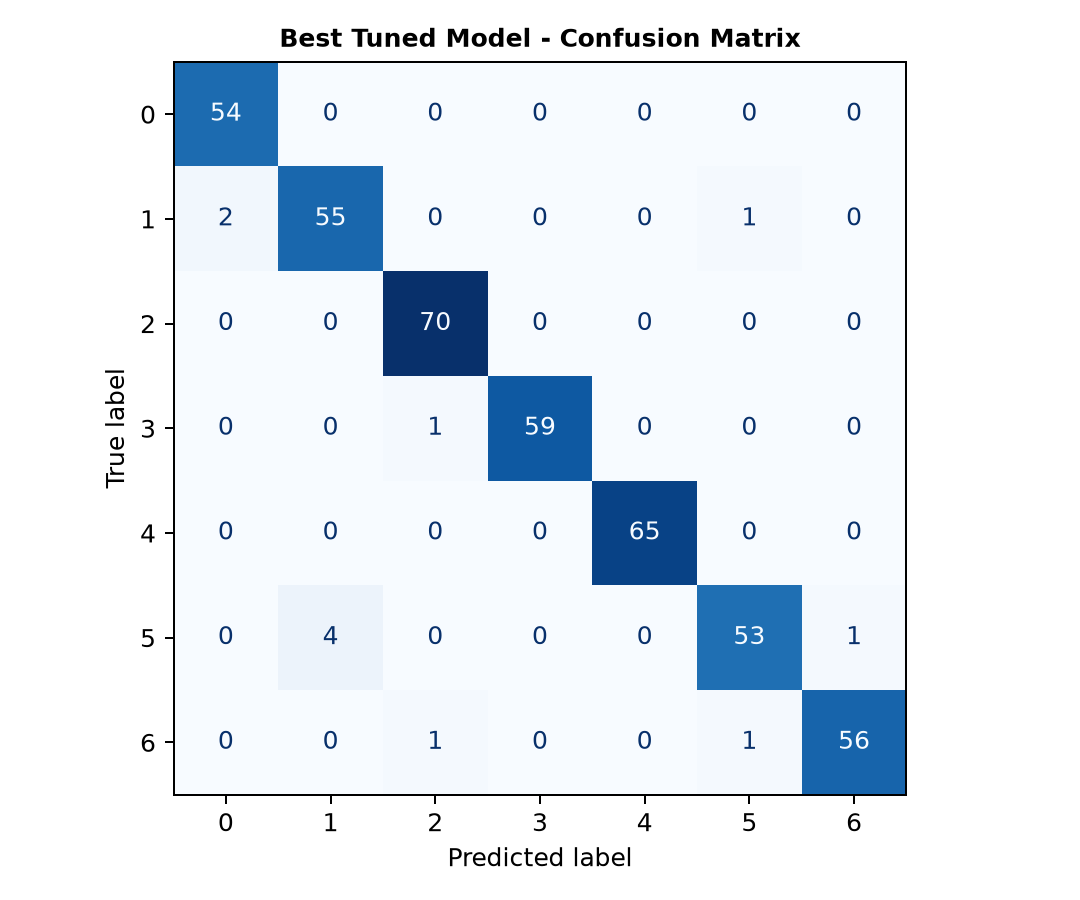

In [6]:
N_TRIALS = 20
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="Optuna_Parent_Tuning") as parent_run:
    mlflow.set_tag("tuned_model", "RandomForestClassifier")

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200, step=25),
            "max_depth": trial.suggest_int("max_depth", 4, 14),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 6),
            "random_state": 42
        }
        with mlflow.start_run(run_name=f"Trial_{trial.number}", nested=True):
            mlflow.log_params(params)
            clf = RandomForestClassifier(**params)
            scores = cross_val_score(clf, X_tr_aug, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
            mean_f1 = float(np.mean(scores))
            mlflow.log_metric("cv_f1_macro", mean_f1)
            return mean_f1

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS)

    print(f"Best CV Macro-F1: {study.best_value:.4f}")
    print(f"Optimal Parameters: {study.best_params}")

    mlflow.log_metric("best_cv_f1_macro", study.best_value)
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})

    # Train and evaluate best model on holdout test set
    best_clf = RandomForestClassifier(**study.best_params, random_state=42)
    best_clf.fit(X_tr_aug, y_train)

    test_preds = best_clf.predict(X_te_aug)
    final_acc = accuracy_score(y_test, test_preds)
    final_f1 = f1_score(y_test, test_preds, average="macro")

    mlflow.log_metrics({"final_accuracy": final_acc, "final_f1_macro": final_f1})
    print(f"Final Holdout Test Accuracy: {final_acc:.4f} | F1-Macro: {final_f1:.4f}")

    # Confusion Matrix Plot
    cm_fig, ax_cm = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, test_preds, ax=ax_cm, cmap="Blues", colorbar=False)
    ax_cm.set_title("Best Tuned Model - Confusion Matrix", fontsize=10, fontweight="bold")
    plt.tight_layout()
    cm_path = "plots/best_confusion_matrix.png"
    cm_fig.savefig(cm_path, dpi=180)
    mlflow.log_artifact(cm_path, "plots")
    plt.show()

    # Register model in MLflow
    signature = infer_signature(X_tr_aug, best_clf.predict(X_tr_aug))
    mlflow.sklearn.log_model(
        sk_model=best_clf,
        artifact_path="optuna_best_random_forest",
        registered_model_name="Obesity_RandomForest_Tuned",
        signature=signature,
        serialization_format="cloudpickle"
    )
    print("Model registered to MLflow as 'Obesity_RandomForest_Tuned'.")


## 6. Conclusion

### Summary of Key Findings:
1. **Dataset & Feature Engineering:**
   - Evaluated the 2019 Obesity Levels dataset (2,111 instances, 7 balanced categories).
   - Engineering $\text{BMI} = \text{Weight} / \text{Height}^2$ was crucial because clinical obesity tiers directly follow BMI ranges.

2. **Dimension Reduction Comparison:**
   - **PCA (Unsupervised):** Compresses 25 features to 6 components while retaining ~85% accuracy.
   - **NMF (Non-negative):** Decomposes data into additive parts; requires non-negative scaling (`MinMaxScaler(clip=True)`).
   - **LDA (Supervised):** Highest efficiency! With only **6 discriminant dimensions**, models reach **>94% accuracy** because LDA specifically maximizes class separability ($S_B / S_W$).
   - **FastICA (Independent Signals):** Extracts non-Gaussian statistical sources (~80% accuracy).
   - **t-SNE (Manifold Learning):** Generates clear 2D visual cluster separation for exploratory data analysis.

3. **Hyperparameter Optimality Analysis:**
   - `max_depth = 8`: Deep enough to capture non-linear eating habit interactions, but constrained enough to prevent memorizing survey noise.
   - `n_estimators = 75`: Stabilizes ensemble variance without redundant computation.
   - `min_samples_split = 2`: Standard split threshold allowing refined class boundaries.